In [2]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
import condacolab
condacolab.check()

root_dir = "/kaggle/working"

# Install `micro-sam` from `conda-forge`.
!mamba install -y -q -c conda-forge micro_sam > /dev/null 2>&1
# GUI backends are not supported in Kaggle / Google Colab, let's remove it to avoid errors.
!pip uninstall -y --quiet napari  

✨🍰✨ Everything looks OK!


In [ ]:
import numpy as np
import torch
from PIL import Image
from skimage.data import cells3d
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation
from IPython.display import clear_output

# clear output because some imports always throw errors/warnings
clear_output(wait=True)

In [3]:

# micro-SAM expects input size (1024, 1024) and will internally resize image, so resize it now
image = Image.open('/kaggle/input/pngfiles/20250811_Dani_Vegetariana_SoI2_Bottom.png')
image = image.resize((1024, 1024)) 
image_arr = np.array(image)
print(image_arr.shape, image.mode)

(1024, 1024) L


# Zero-Shot Inference without Prompts

In [4]:
#Convert micro-SAM instance array (H,W) to SAM-style mask list
def convert_instances_to_SAM_masks(instances):
    masks = []
    instance_ids = np.unique(instances)
    for inst_id in instance_ids:
        mask_bool = (instances == inst_id)
        masks.append({
            'segmentation': mask_bool,
            'area': int(mask_bool.sum())
        })
        
    return masks

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)  

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

predictor, segmenter = get_predictor_and_segmenter(
    model_type="vit_b_lm",
    device=device,
    amg=True
)

instances = automatic_instance_segmentation(
    predictor=predictor,
    segmenter=segmenter,
    input_path=image_arr,
)

100%|████████████████████████████████████████| 375M/375M [00:00<00:00, 435GB/s]
100%|█████████████████████████████████████| 38.4M/38.4M [00:00<00:00, 45.5GB/s]
Predict masks for point grid prompts: 100%|██████████| 16/16 [00:18<00:00,  1.14s/it]


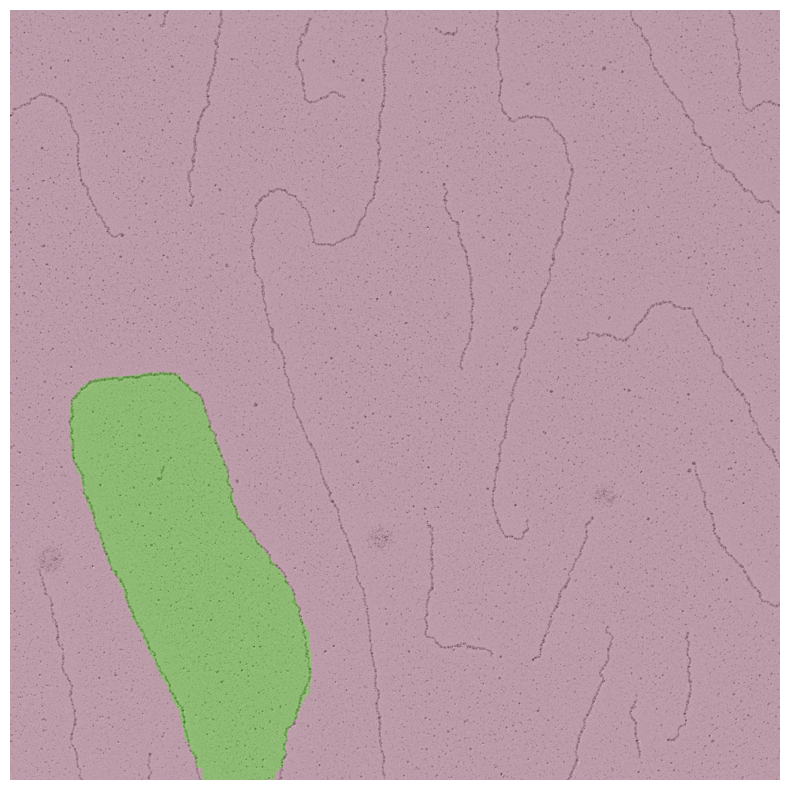

In [6]:
from matplotlib import pyplot as plt

masks = convert_instances_to_SAM_masks(instances)

plt.figure(figsize=(10,10))
plt.imshow(image_arr, cmap='gray')
show_anns(masks)
plt.axis('off')
plt.show()